# RLSSM Simulator Demo

This notebook demonstrates the core `ssms.rl` API for simulating reinforcement-learning sequential sampling models (RLSSMs).

An RLSSM simulation interleaves learning and decision making on every trial:

1. the learning state, such as Q-values, computes SSM parameters such as drift `v`;
2. an SSM decision process simulates response time and response label;
3. the task environment returns feedback for the chosen action;
4. the learning rule updates before the next trial.

The examples below show the preset API, explicit component composition, task shorthand configuration, response/action mapping, generated data inspection, plots, the compiled-model interface, and the HSSM config bridge.

In [25]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import ssms.rl as rl

pd.set_option("display.max_columns", 20)
plt.style.use("seaborn-v0_8-whitegrid")

## 1. Quick Start: Preset Simulation

The fastest path is to load a named preset, create a simulator, and pass concrete parameter values through `theta`. The built-in `rlssm1` preset combines a Rescorla-Wagner learner, an angle decision process, and a two-arm Bernoulli bandit.

In [26]:
print("Available presets:", rl.preset.list())

bernoulli_config = rl.preset.get("rlssm1")
bernoulli_theta = {
    "rl_alpha": 0.1,
    "scaler": 2.0,
    "a": 1.5,
    "z": 0.5,
    "t": 0.15,
    "theta": 0.1,
}

print(f"Model: {bernoulli_config.model_name}")
print(f"Decision process: {bernoulli_config.decision_process}")
print(f"Learning process: {type(bernoulli_config.learning_process).__name__}")
print(f"Response labels: {bernoulli_config.choices}")
print(f"Response -> action mapping: {bernoulli_config.response_to_action}")
print(f"Free parameters: {bernoulli_config.list_params}")

Available presets: ['rlssm1']
Model: rlssm1
Decision process: angle
Learning process: RescorlaWagnerDeltaRule
Response labels: (-1, 1)
Response -> action mapping: {-1: 0, 1: 1}
Free parameters: ['rl_alpha', 'scaler', 'a', 'z', 't', 'theta']


In [27]:
bernoulli_sim = rl.Simulator(bernoulli_config)
bernoulli_data = bernoulli_sim.simulate(
    theta=bernoulli_theta,
    n_trials=200,
    n_participants=20,
    random_state=42,
)

print(f"Shape: {bernoulli_data.shape}")
print(f"Columns: {list(bernoulli_data.columns)}")
bernoulli_data.head(8)

Shape: (4000, 5)
Columns: ['participant_id', 'trial_id', 'rt', 'response', 'feedback']


,participant_id,trial_id,rt,response,feedback
0,0,0,2.925990,1,0.0
1,0,1,3.179487,1,0.0
2,0,2,0.925149,-1,0.0
3,0,3,1.190909,-1,1.0
4,0,4,0.906847,-1,0.0
5,0,5,3.177333,-1,1.0
6,0,6,3.084774,1,0.0
7,0,7,1.105568,-1,1.0


## 2. Configuring Models

The simulator API is compositional: a `ModelConfig` combines one decision process, one learning process, and one task environment. The config describes model structure; concrete parameter values stay in `theta`.

In [28]:
gaussian_config = rl.ModelConfig(
    model_name="rlssm_angle_dual_alpha_gaussian",
    description="Dual-alpha Rescorla-Wagner + angle + Gaussian bandit",
    decision_process="angle",
    learning_process=rl.learning.RescorlaWagnerDualAlphaRule(),
    task_environment=rl.env.Bandit.gaussian(
        means=[0.8, 0.2],
        sds=[0.25, 0.25],
        response_labels=[-1, 1],
    ),
)

gaussian_theta = {
    "rl_alpha": 0.3,
    "rl_alpha_neg": 0.1,
    "scaler": 2.0,
    "a": 1.5,
    "z": 0.5,
    "t": 0.3,
    "theta": 0.2,
}

print(f"Model: {gaussian_config.model_name}")
print(f"Learning process: {type(gaussian_config.learning_process).__name__}")
print(f"Free parameters: {gaussian_config.list_params}")
print(f"Computed SSM parameters: {gaussian_config.learning_process.computed_params}")

Model: rlssm_angle_dual_alpha_gaussian
Learning process: RescorlaWagnerDualAlphaRule
Free parameters: ['rl_alpha', 'rl_alpha_neg', 'scaler', 'a', 'z', 't', 'theta']
Computed SSM parameters: ['v']


In [29]:
taskconfig_config = rl.ModelConfig(
    model_name="taskconfig_bernoulli_rlssm",
    description="TaskConfig shorthand for a Bernoulli bandit",
    decision_process="angle",
    learning_process=rl.learning.RescorlaWagnerDeltaRule(),
    task_environment=rl.env.TaskConfig(
        task="bandit",
        reward="bernoulli",
        probabilities=[0.65, 0.35],
        response_labels=[-1, 1],
    ),
)

print(f"TaskConfig built: {type(taskconfig_config.task_environment).__name__}")
print(f"Registered task shorthands: {rl.env.registered_tasks()}")

TaskConfig built: Bandit
Registered task shorthands: ['bandit']


In [30]:
def summarize_config(label, config, reward_kind):
    return {
        "example": label,
        "model": config.model_name,
        "decision": config.decision_process,
        "learning": type(config.learning_process).__name__,
        "reward": reward_kind,
        "response_labels": tuple(config.choices),
        "computed": tuple(config.learning_process.computed_params),
        "free_params": tuple(config.list_params),
    }


config_summary = pd.DataFrame(
    [
        summarize_config("preset", bernoulli_config, "Bernoulli"),
        summarize_config("components", gaussian_config, "Gaussian"),
        summarize_config("TaskConfig", taskconfig_config, "Bernoulli"),
    ]
)
config_summary

,example,model,decision,learning,reward,response_labels,computed,free_params
0,preset,rlssm1,angle,RescorlaWagnerDeltaRule,Bernoulli,"(-1, 1)","(v,)","(rl_alpha, scaler, a, z, t, theta)"
1,components,rlssm_angle_dual_alpha_gaussian,angle,RescorlaWagnerDualAlphaRule,Gaussian,"(-1, 1)","(v,)","(rl_alpha, rl_alpha_neg, scaler, a, z, t, theta)"
2,TaskConfig,taskconfig_bernoulli_rlssm,angle,RescorlaWagnerDeltaRule,Bernoulli,"(-1, 1)","(v,)","(rl_alpha, scaler, a, z, t, theta)"


## 3. Response Labels vs Learning Actions

SSM decision processes can emit response labels such as `-1` and `1`. Learning rules and task environments use zero-based action indices. `response_mapping="auto"` derives the mapping from the environment's response-label order, and `include_action=True` can add the derived action to the simulated data for inspection.

In [31]:
mapping_config = rl.ModelConfig(
    model_name="response_action_demo",
    description="Expose derived actions for response-label inspection",
    decision_process="angle",
    learning_process=rl.learning.RescorlaWagnerDeltaRule(),
    task_environment=rl.env.Bandit.bernoulli(
        probabilities=[0.7, 0.3],
        response_labels=[-1, 1],
    ),
    include_action=True,
)

mapping_data = rl.Simulator(mapping_config).simulate(
    theta=bernoulli_theta,
    n_trials=12,
    n_participants=1,
    random_state=7,
)

print(f"Response -> action mapping: {mapping_config.response_to_action}")
mapping_data[["participant_id", "trial_id", "rt", "response", "action", "feedback"]]

Response -> action mapping: {-1: 0, 1: 1}


,participant_id,trial_id,rt,response,action,feedback
0,0,0,1.256809,1,1,1.0
1,0,1,1.437518,1,1,0.0
2,0,2,2.189805,-1,0,0.0
3,0,3,0.987093,1,1,1.0
4,0,4,1.034955,1,1,0.0
5,0,5,1.244467,1,1,1.0
6,0,6,2.295517,-1,0,1.0
7,0,7,3.380327,1,1,0.0
8,0,8,3.858962,1,1,0.0
9,0,9,2.201911,-1,0,1.0


## 4. Worked Simulation Variants

The remaining sections compare two simulated datasets: the Bernoulli preset and an explicit Gaussian/dual-alpha model.

In [32]:
gaussian_sim = rl.Simulator(gaussian_config)
gaussian_data = gaussian_sim.simulate(
    theta=gaussian_theta,
    n_trials=200,
    n_participants=20,
    random_state=123,
)

print(f"Gaussian data shape: {gaussian_data.shape}")
print(
    "Gaussian feedback range: "
    f"{gaussian_data['feedback'].min():.3f} to {gaussian_data['feedback'].max():.3f}"
)
gaussian_data.head(8)

Gaussian data shape: (4000, 5)
Gaussian feedback range: -0.309 to 1.947


,participant_id,trial_id,rt,response,feedback
0,0,0,1.533501,-1,0.788125
1,0,1,1.006936,-1,0.772137
2,0,2,2.617165,-1,1.028608
3,0,3,1.383640,-1,0.907379
4,0,4,1.128517,-1,0.937621
5,0,5,2.942698,-1,0.381145
6,0,6,0.865283,-1,0.915096
7,0,7,1.623786,-1,0.817361


In [33]:
rlssm_datasets = {
    "bernoulli": {
        "label": "Bernoulli bandit + single alpha",
        "data": bernoulli_data,
        "config": bernoulli_config,
        "theta": bernoulli_theta,
        "reward_values": [0.7, 0.3],
        "target_label": "high reward-probability arm",
    },
    "gaussian": {
        "label": "Gaussian bandit + dual alpha",
        "data": gaussian_data,
        "config": gaussian_config,
        "theta": gaussian_theta,
        "reward_values": [0.8, 0.2],
        "target_label": "high mean-reward arm",
    },
}

## 5. Inspecting Generated Data

Simulator output is a participant-by-trial panel with response times, SSM response labels, feedback, and optional task fields. These checks focus on the shape HSSM expects: participant-contiguous rows, balanced trial counts, and required columns.

In [34]:
REQUIRED_COLUMNS = {"participant_id", "trial_id", "rt", "response", "feedback"}


def inspect_dataset(dataset_key):
    dataset = rlssm_datasets[dataset_key]
    df = dataset["data"]
    sorted_panel = df.equals(df.sort_values(["participant_id", "trial_id"]).reset_index(drop=True))
    trials_per_participant = df.groupby("participant_id").size()
    missing_required = sorted(REQUIRED_COLUMNS - set(df.columns))
    return {
        "dataset": dataset["label"],
        "rows": len(df),
        "participants": df["participant_id"].nunique(),
        "trials_per_participant": tuple(sorted(trials_per_participant.unique())),
        "balanced": trials_per_participant.nunique() == 1,
        "sorted": sorted_panel,
        "missing_required_columns": missing_required,
        "response_labels": tuple(sorted(df["response"].unique())),
        "feedback_min": df["feedback"].min(),
        "feedback_max": df["feedback"].max(),
        "omissions": int((df["response"] == -999).sum()),
    }


inspection = pd.DataFrame(
    [inspect_dataset("bernoulli"), inspect_dataset("gaussian")]
)
inspection

,dataset,rows,participants,trials_per_participant,balanced,sorted,missing_required_columns,response_labels,feedback_min,feedback_max,omissions
0,Bernoulli bandit + single alpha,4000,20,"(200,)",True,True,[],"(-1, 1)",0.000000,1.000000,0
1,Gaussian bandit + dual alpha,4000,20,"(200,)",True,True,[],"(-1, 1)",-0.309363,1.946633,0


In [35]:
summary_rows = []
for dataset_key, dataset in rlssm_datasets.items():
    df = dataset["data"]
    summary_rows.append(
        {
            "dataset": dataset["label"],
            "mean_rt": df["rt"].mean(),
            "median_rt": df["rt"].median(),
            "mean_feedback": df["feedback"].mean(),
            "p_response_-1": (df["response"] == -1).mean(),
            "p_response_1": (df["response"] == 1).mean(),
        }
    )

pd.DataFrame(summary_rows)

,dataset,mean_rt,median_rt,mean_feedback,p_response_-1,p_response_1
0,Bernoulli bandit + single alpha,1.583278,1.316670,0.63850,0.85225,0.14775
1,Gaussian bandit + dual alpha,1.381850,1.205391,0.76183,0.93100,0.06900


## 6. Visualizing Learning and Decisions

The plots below summarize group-level learning, participant-level latent dynamics reconstructed from responses and feedback, and response-time distributions.

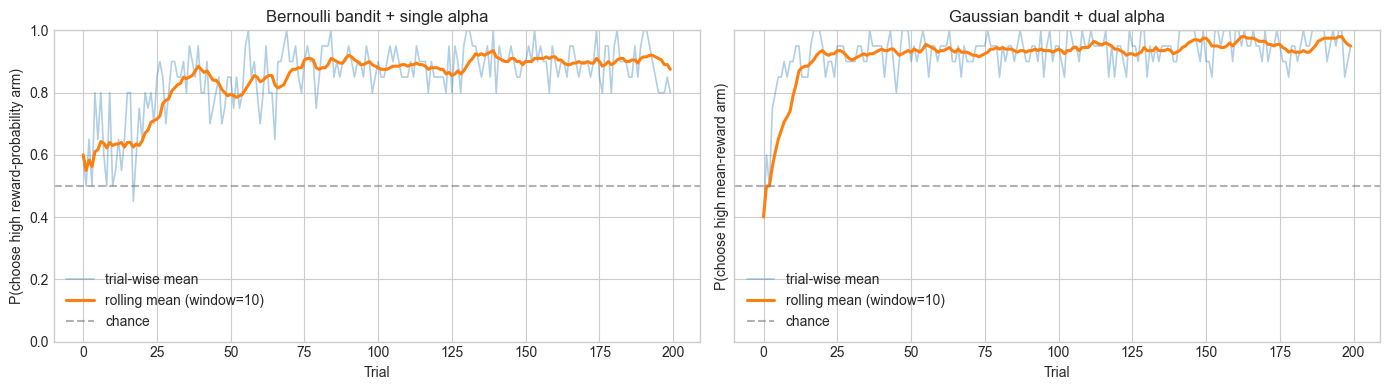

In [36]:
def target_response(dataset):
    reward_values = dataset["reward_values"]
    target_action = int(np.argmax(reward_values))
    return dataset["config"].task_environment.response_labels[target_action]


def plot_learning_curve(dataset_key, window=10, ax=None):
    dataset = rlssm_datasets[dataset_key]
    df = dataset["data"]
    target = target_response(dataset)

    learning_curve = (
        df.assign(chose_target=(df["response"] == target).astype(float))
        .groupby("trial_id", as_index=False)["chose_target"]
        .mean()
        .rename(columns={"chose_target": "p_target"})
    )

    if ax is None:
        _, ax = plt.subplots(figsize=(8, 4))

    ax.plot(
        learning_curve["trial_id"],
        learning_curve["p_target"],
        alpha=0.35,
        linewidth=1.2,
        label="trial-wise mean",
    )
    ax.plot(
        learning_curve["trial_id"],
        learning_curve["p_target"].rolling(window=window, min_periods=1).mean(),
        linewidth=2.2,
        label=f"rolling mean (window={window})",
    )
    ax.axhline(0.5, color="gray", linestyle="--", alpha=0.6, label="chance")
    ax.set_xlabel("Trial")
    ax.set_ylabel(f"P(choose {dataset['target_label']})")
    ax.set_title(dataset["label"])
    ax.set_ylim(0, 1)
    ax.legend()
    return ax


fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
plot_learning_curve("bernoulli", ax=axes[0])
plot_learning_curve("gaussian", ax=axes[1])
plt.tight_layout()
plt.show()

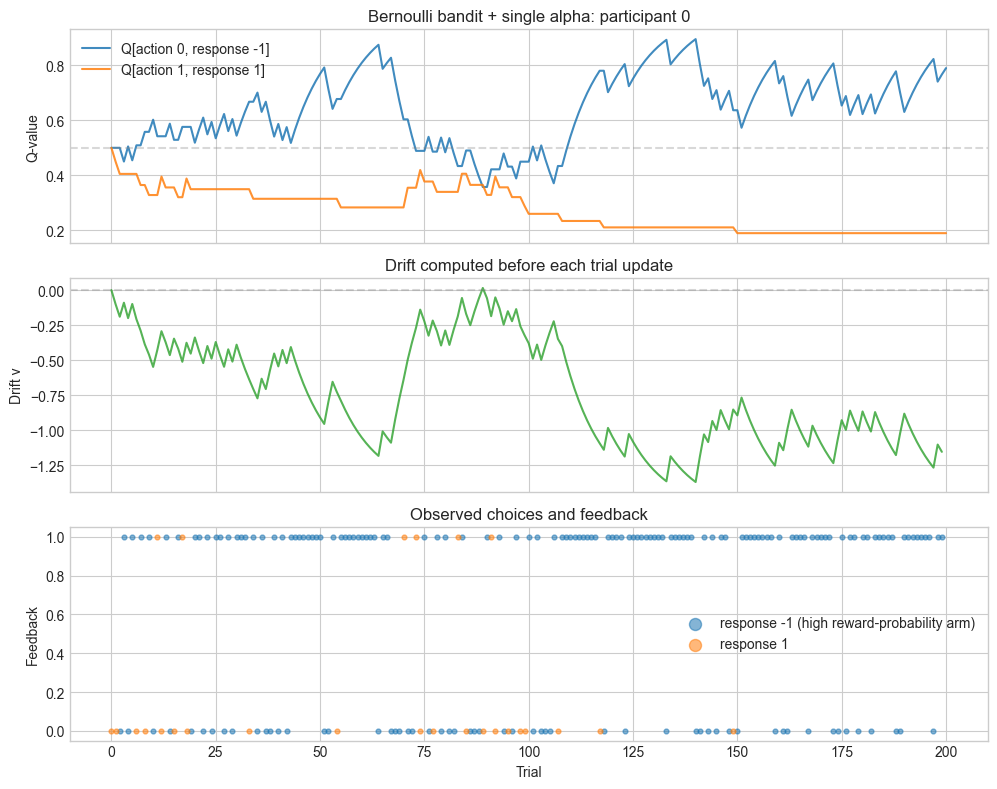

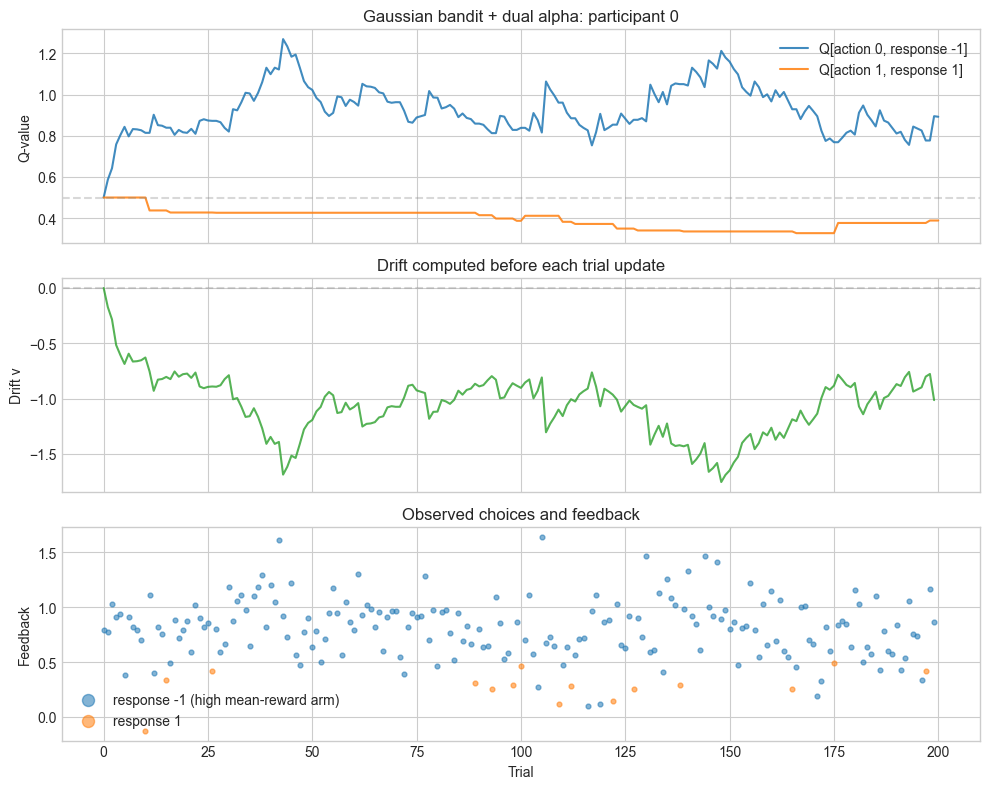

In [37]:
def replay_learning_dynamics(dataset_key, participant_id=0):
    dataset = rlssm_datasets[dataset_key]
    df = dataset["data"]
    config = dataset["config"]
    theta = dataset["theta"]
    subj_data = df[df["participant_id"] == participant_id].copy().reset_index(drop=True)

    q_vals = np.full(config.task_environment.n_arms, 0.5, dtype=float)
    q_history = [q_vals.copy()]
    drift_history = []

    for _, row in subj_data.iterrows():
        drift_history.append((q_vals[1] - q_vals[0]) * theta["scaler"])
        if int(row["response"]) == -999:
            q_history.append(q_vals.copy())
            continue

        action = config.response_to_action[int(row["response"])]
        reward = float(row["feedback"])
        delta = reward - q_vals[action]
        alpha = theta["rl_alpha_neg"] if delta < 0 and "rl_alpha_neg" in theta else theta["rl_alpha"]
        q_vals[action] += alpha * delta
        q_history.append(q_vals.copy())

    return subj_data, np.array(q_history), np.array(drift_history)


def plot_learning_dynamics(dataset_key, participant_id=0):
    dataset = rlssm_datasets[dataset_key]
    config = dataset["config"]
    labels = list(config.task_environment.response_labels)
    target = target_response(dataset)
    other = [label for label in labels if label != target][0]
    subj_data, q_history, drift_history = replay_learning_dynamics(
        dataset_key, participant_id=participant_id
    )

    fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

    for action, label in enumerate(labels):
        axes[0].plot(q_history[:, action], label=f"Q[action {action}, response {label}]", alpha=0.85)
    axes[0].set_ylabel("Q-value")
    axes[0].set_title(f"{dataset['label']}: participant {participant_id}")
    axes[0].legend()
    axes[0].axhline(0.5, color="gray", linestyle="--", alpha=0.3)

    axes[1].plot(drift_history, color="C2", alpha=0.8)
    axes[1].set_ylabel("Drift v")
    axes[1].set_title("Drift computed before each trial update")
    axes[1].axhline(0, color="gray", linestyle="--", alpha=0.3)

    responses = subj_data["response"].to_numpy()
    rewards = subj_data["feedback"].to_numpy()
    trials = np.arange(len(responses))
    axes[2].scatter(
        trials[responses == target],
        rewards[responses == target],
        c="C0",
        s=12,
        alpha=0.55,
        label=f"response {target} ({dataset['target_label']})",
    )
    axes[2].scatter(
        trials[responses == other],
        rewards[responses == other],
        c="C1",
        s=12,
        alpha=0.55,
        label=f"response {other}",
    )
    axes[2].set_ylabel("Feedback")
    axes[2].set_xlabel("Trial")
    axes[2].set_title("Observed choices and feedback")
    axes[2].legend(markerscale=2.5)

    plt.tight_layout()
    plt.show()


for dataset_key in ["bernoulli", "gaussian"]:
    plot_learning_dynamics(dataset_key, participant_id=0)

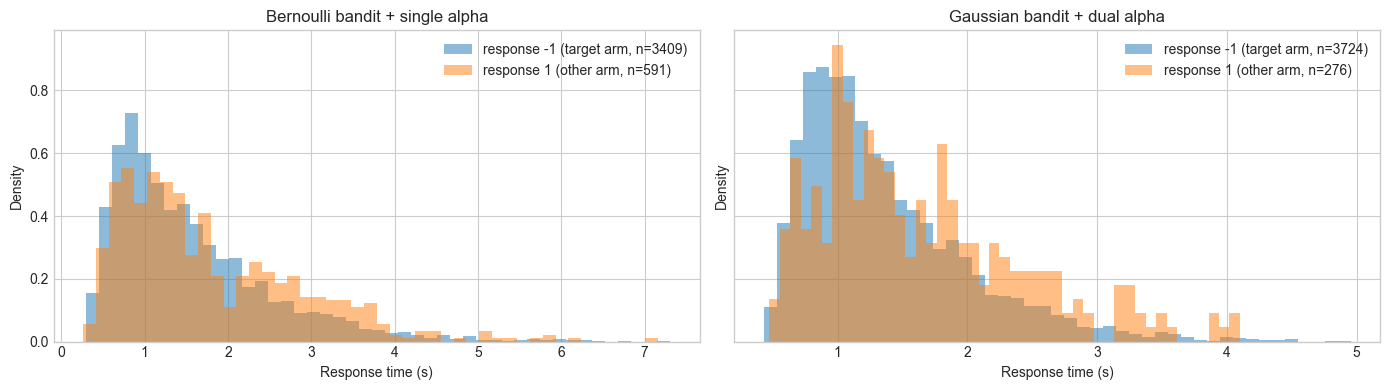

In [38]:
def plot_rt_distributions(dataset_key, ax=None):
    dataset = rlssm_datasets[dataset_key]
    df = dataset["data"]
    labels = list(dataset["config"].task_environment.response_labels)
    target = target_response(dataset)

    if ax is None:
        _, ax = plt.subplots(figsize=(8, 4))

    for label, color in zip(labels, ["C0", "C1", "C2", "C3"]):
        role = "target arm" if label == target else "other arm"
        rts = df.loc[df["response"] == label, "rt"]
        ax.hist(
            rts,
            bins=45,
            alpha=0.5,
            label=f"response {label} ({role}, n={len(rts)})",
            color=color,
            density=True,
        )

    ax.set_xlabel("Response time (s)")
    ax.set_ylabel("Density")
    ax.set_title(dataset["label"])
    ax.legend()
    return ax


fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
plot_rt_distributions("bernoulli", ax=axes[0])
plot_rt_distributions("gaussian", ax=axes[1])
plt.tight_layout()
plt.show()

## 7. Compiled Model and HSSM Bridge

For inference-oriented workflows, compile a validated model and derive participant-history layouts from the same `ModelConfig` users specify for simulation.

- `ModelConfig.outcome_field` names the reward/outcome column (default `"feedback"`)
- `config.compile()` returns a `CompiledModel` with backend metadata
- `compiled.compile_participant_fn()` works with no kwargs for standard models
- `to_hssm_config_dict()` exports structural fields plus a `participant_contract` snapshot

HSSM still fills inference-only likelihood wiring today; a higher-level `hssm.RLSSM(data, model=...)` API is tracked separately.

In [ ]:
compiled = bernoulli_config.compile(backend="python")
print("Participant input fields:", compiled.participant_input_fields())
compute_v = compiled.compile_participant_fn()
print("Compiled outputs:", compiled.computed_params)

hssm_config = gaussian_config.to_hssm_config_dict()
important_keys = [
    "model_name",
    "decision_process",
    "list_params",
    "choices",
    "response",
    "response_mapping",
    "extra_fields",
    "learning_backend",
    "gradient",
    "learning_process_kind",
    "participant_contract",
]

for key in important_keys:
    print(f"{key}: {hssm_config[key]!r}")